In [1]:
# this file will test the XFuse Module on some example porespy data


In [2]:
from x_fuse.utils import get_multiphase, downsample_xrdct, xrd_to_tensor
from x_fuse.fusion import XFuse
import numpy as np
import porespy as ps
import matplotlib.pyplot as plt
import torch
import porespy as ps
from PIL import Image
import hr_dv2.transform as tr
from hr_dv2.utils import do_single_pca, rescale_pca
import torchvision.transforms as transforms

In [3]:
# create the dataset

IMG_SIZE = 224
N_SAMPLES = 10

ps_dict = {"blobs": ps.generators.blobs, "rand_spheres": ps.generators.random_spheres}

im1 = ps_dict["blobs"]
im2 = ps_dict["rand_spheres"]

im1_kwargs = {'shape': [IMG_SIZE, IMG_SIZE], 'blobiness': 0.5, 'porosity': 0.4}
im2_kwargs = {'r': 20, 'clearance': 10}

gray_imgs, phase_A_masks, phase_B_masks = get_multiphase(im1, im1_kwargs, im2, im2_kwargs, extract_spheres=True, dataset_size=10)

In [4]:
gray_imgs, low_A, low_B = downsample_xrdct(gray_imgs, phase_A_masks, phase_B_masks, factor=10)

In [5]:
# refine the data

xct_img = gray_imgs[0]
xrd_A = low_A[0]
xrd_B = low_B[0]

In [6]:
# now I have my dataset I can test the XFuse Module

DINO_MODEL = "dinov2_vits14"
PATCH_SIZE = 14
STRIDE = 8
PATCH_H, PATCH_W = IMG_SIZE // PATCH_SIZE, IMG_SIZE // PATCH_SIZE
FUSION_METHOD = 'gating'

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

Using device: mps


In [7]:
net = XFuse(DINO_MODEL, FUSION_METHOD, stride=STRIDE, pca_dim=-1, track_grad=False, dtype=torch.float16, device=DEVICE)

Using cache found in /Users/trb56939/.cache/torch/hub/facebookresearch_dinov2_main
/Users/trb56939/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/trb56939/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/trb56939/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Using cache found in /Users/trb56939/.cache/torch/hub/facebookresearch_dinov2_main


In [8]:
h, w = xct_img.shape
print(f"XCT image shape: {xct_img.shape}, Phase A mask shape: {xrd_A.shape}, Phase B mask shape: {xrd_B.shape}")

XCT image shape: (224, 224), Phase A mask shape: (22, 22), Phase B mask shape: (22, 22)


In [9]:
xct_img_tr = tr.closest_crop(xct_img, PATCH_H, PATCH_W)
xct_img_tr = tr.get_input_transform(IMG_SIZE, IMG_SIZE)


def load_img(img, transform):
    unnormalize = transforms.Normalize(
    mean=(-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225),
    std=(1 / 0.229, 1 / 0.224, 1 / 0.225),
)
    image = Image.fromarray(img).convert("RGB")
    tensor = transform(image)
    trans_img = transforms.ToPILImage(unnormalize(tensor))

    return tensor, trans_img

In [10]:
xct_tensor, xct_image = load_img(xct_img, xct_img_tr)

xct_tensor = xct_tensor.to(torch.float16).to(DEVICE)
print(DEVICE)

xrd_A_tensor = xrd_to_tensor(xrd_A, DEVICE)
xrd_B_tensor = xrd_to_tensor(xrd_B, DEVICE)

print(xct_tensor.device)

mps
mps:0


In [26]:
shift_dists = [i for i in range(1,3)]

fwd_shift, inv_shift = tr.get_shift_transforms(shift_dists, 'Moore')
fwd_flip, inv_flip = tr.get_flip_transforms()
fwd, inv = tr.combine_transforms(fwd_shift, fwd_flip, inv_shift, inv_flip)

net.set_xrd_transforms(xrd_B_tensor, fwd, inv)

print(f"XRD Tensor shape: {xrd_B_tensor.shape}", f"XCT Tensor shape: {xct_tensor.shape}")

XRD Tensor shape: torch.Size([1, 1, 22, 22]) XCT Tensor shape: torch.Size([3, 224, 224])


In [27]:
attn_choice = 'none'

feats_tensor = net.forward_sequential(xct_tensor)

XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0

In [ ]:
feats = feats_tensor[0]
feats_np = tr.to_numpy(feats)
feats_flat = tr.flatten(feats_np, feats_np.shape[1], feats_np.shape[2], feats_np.shape[0])
print(min(feats_flat.flatten()), max(feats_flat.flatten()))
pcaed = do_single_pca(feats_flat, 3, n_samples=5000)
rescaled = rescale_pca(pcaed)
print(rescaled.shape)

-2.602 3.176


XCT image shape: (224, 224), Rescaled PCA shape: (224, 224, 3)


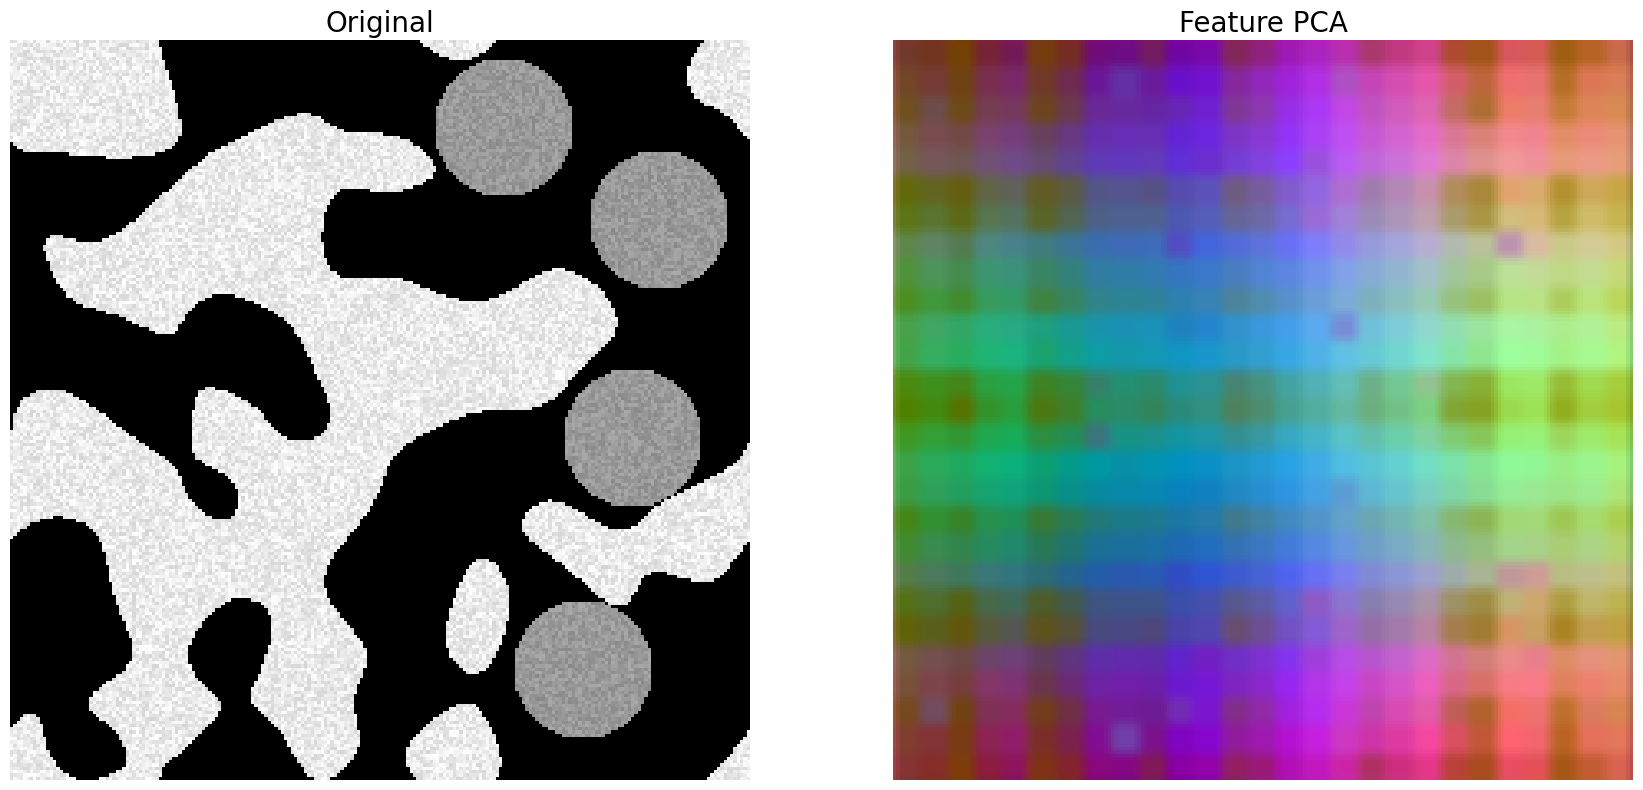

In [33]:
fig, axs = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(18, 8)

axs[0].imshow(xct_img, cmap='gray')
axs[1].imshow(rescaled.reshape(IMG_SIZE, IMG_SIZE, 3), interpolation='nearest')
# axs[2].imshow(np.sum(tr.to_numpy(attn), axis=0) , interpolation='nearest')

print(f"XCT image shape: {xct_img.shape}, Rescaled PCA shape: {rescaled.reshape(IMG_SIZE, IMG_SIZE, 3).shape}")

titles = ["Original", "Feature PCA", "sum [CLS] attn"]
for i, ax in enumerate(axs):
    ax.set_axis_off()
    ax.set_title(titles[i], fontsize=20)
plt.tight_layout()

In [17]:
print(min(rescaled.flatten()), max(rescaled.flatten()))

0.0 1.0


In [35]:
from hr_dv2.high_res import HighResDV2

net2 = HighResDV2(DINO_MODEL, 8, track_grad=False, dtype=torch.float16, device=DEVICE)
net.set_transforms(fwd, inv)

Using cache found in /Users/trb56939/.cache/torch/hub/facebookresearch_dinov2_main


In [36]:
net.forward_sequential(xct_tensor)

XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0
XRD map shape after unsqueeze: torch.Size([1, 1, 22, 22])
Feature shape: torch.Size([1, 384, 27, 27])
Feature Device: mps:0, XRD Device: mps:0

tensor([[[[ 7.8125e-02,  7.5562e-02,  7.4097e-02,  ...,  8.0322e-02,
            8.0750e-02,  8.0444e-02],
          [ 7.8369e-02,  7.5623e-02,  7.4158e-02,  ...,  8.0688e-02,
            8.1177e-02,  8.0811e-02],
          [ 7.8613e-02,  7.5806e-02,  7.3975e-02,  ...,  8.1238e-02,
            8.1665e-02,  8.1360e-02],
          ...,
          [ 7.5623e-02,  7.4036e-02,  7.3547e-02,  ...,  7.6599e-02,
            7.6782e-02,  7.6477e-02],
          [ 7.5867e-02,  7.4341e-02,  7.3181e-02,  ...,  7.7332e-02,
            7.7637e-02,  7.7271e-02],
          [ 7.6294e-02,  7.4219e-02,  7.3059e-02,  ...,  7.8552e-02,
            7.8796e-02,  7.8308e-02]],

         [[-3.5400e-01, -4.9536e-01, -5.7324e-01,  ...,  4.5898e-01,
            2.2290e-01, -1.8539e-02],
          [-3.4985e-01, -4.9072e-01, -5.6836e-01,  ...,  4.6240e-01,
            2.2607e-01, -1.4732e-02],
          [-3.4619e-01, -4.8804e-01, -5.6543e-01,  ...,  4.6436e-01,
            2.2852e-01, -1.2268e-02],
          ...,
     

In [37]:
feats = feats_tensor[0]
feats_np = tr.to_numpy(feats)
feats_flat = tr.flatten(feats_np, feats_np.shape[1], feats_np.shape[2], feats_np.shape[0])
print(min(feats_flat.flatten()), max(feats_flat.flatten()))
pcaed = do_single_pca(feats_flat, 3, n_samples=5000)
rescaled = rescale_pca(pcaed)
print(rescaled.shape)

-2.602 3.176
(50176, 3)


XCT image shape: (224, 224), Rescaled PCA shape: (224, 224, 3)


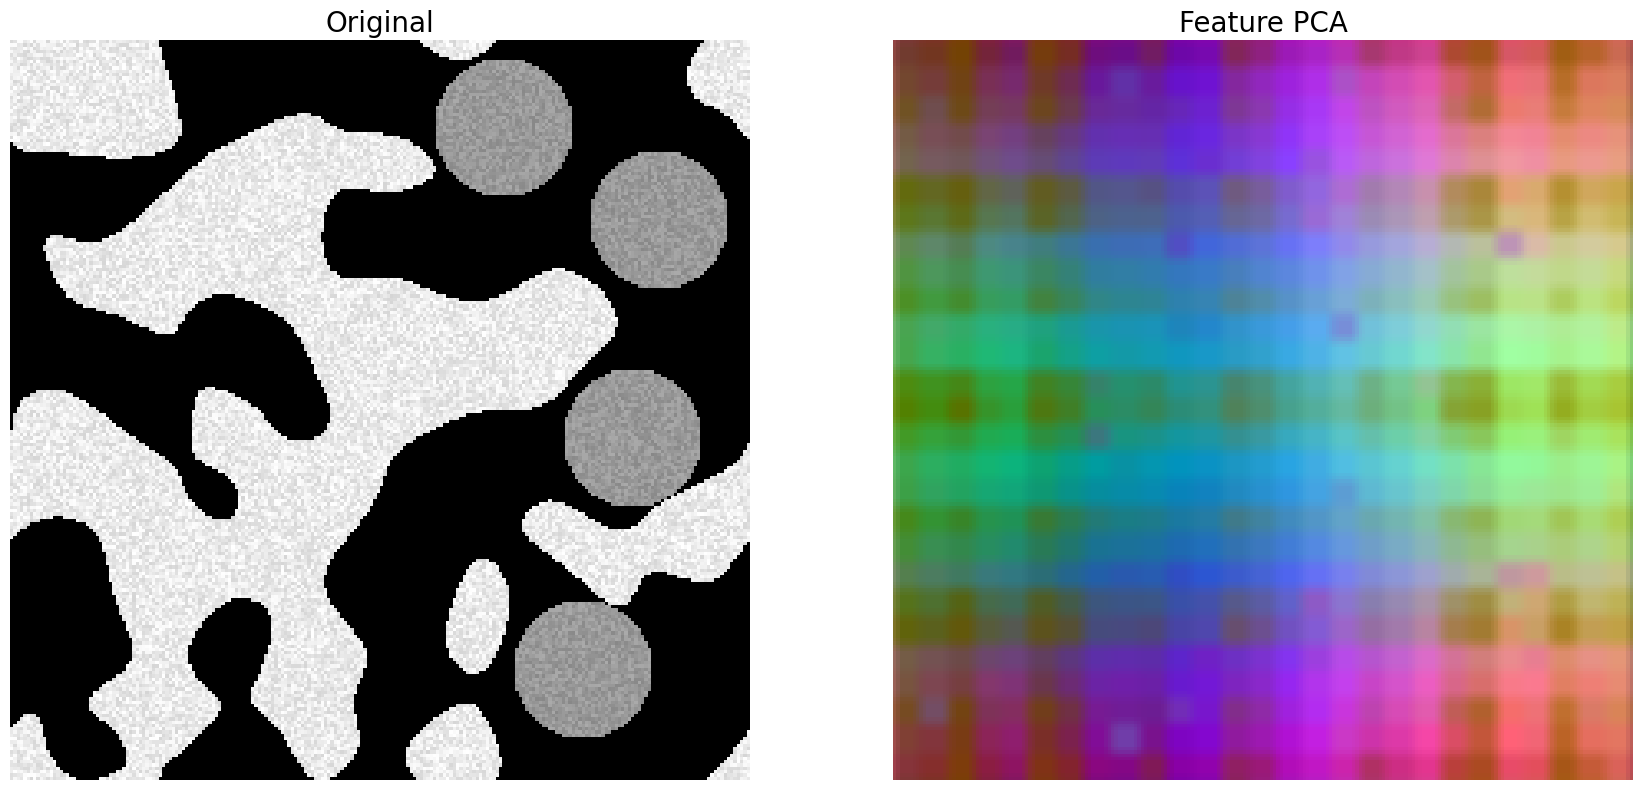

In [38]:
fig, axs = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(18, 8)

axs[0].imshow(xct_img, cmap='gray')
axs[1].imshow(rescaled.reshape(IMG_SIZE, IMG_SIZE, 3), interpolation='nearest')
# axs[2].imshow(np.sum(tr.to_numpy(attn), axis=0) , interpolation='nearest')

print(f"XCT image shape: {xct_img.shape}, Rescaled PCA shape: {rescaled.reshape(IMG_SIZE, IMG_SIZE, 3).shape}")

titles = ["Original", "Feature PCA", "sum [CLS] attn"]
for i, ax in enumerate(axs):
    ax.set_axis_off()
    ax.set_title(titles[i], fontsize=20)
plt.tight_layout()